# 2.4 Self-RAG Agent 버전

기존 `StateGraph` 기반 Self-RAG 예제를 `create_agent()` 기반 Agent 구조로 변경한 버전입니다.

- 기존 `retrieve` 노드 → `search_pension_law` tool
- 기존 `rewrite` 노드 → `rewrite_query_by_dictionary()` 함수 + system prompt 지시
- 기존 hallucination/helpfulness 검증 → Agent system prompt의 자기 점검 규칙으로 반영
- 필요하면 `verify_answer_with_docs()`를 별도로 호출해서 근거 기반 여부를 확인할 수 있습니다.

> Agent 버전에서는 그래프 노드가 `retrieve`, `generate`, `rewrite`처럼 세분화되어 보이지 않고 보통 `model ↔ tools` 구조로 보입니다.

In [2]:
from dotenv import load_dotenv
from langchain_chroma import Chroma
from langchain_upstage import UpstageEmbeddings, ChatUpstage

load_dotenv()

embedding_function = UpstageEmbeddings(model="solar-embedding-1-large")

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name="pension_law_collection",
    persist_directory="./pension_law_collection",
)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})
llm = ChatUpstage()

In [3]:
# 사용자의 표현을 국민연금 법령 용어로 바꾸기 위한 간단한 사전입니다.
dictionary = [
    "직장인 -> 사업장가입자",
    "회사원 -> 사업장가입자",
    "근로자 -> 사업장가입자",
    "개인사업자 -> 지역가입자",
    "자영업자 -> 지역가입자",
    "프리랜서 -> 지역가입자",
    "학생 -> 임의가입자",
    "전업주부 -> 임의가입자",
    "주부 -> 임의가입자",
    "외국인 -> 외국인가입자",
    "연금 보험료 -> 연금보험료",
    "국민연금 보험료 -> 연금보험료",
    "보험료 미납 -> 연금보험료 체납",
    "연금 못 냄 -> 연금보험료 체납",
    "가입 해지 -> 가입자 자격 상실",
    "탈퇴 -> 가입자 자격 상실",
    "가입 시작일 -> 자격 취득 시기",
    "가입 끝나는 날 -> 자격 상실 시기",
    "수급자 -> 수급권자",
    "연금 받는 사람 -> 수급권자",
    "노후연금 -> 노령연금",
    "장애 보상 -> 장애연금",
    "사망 후 연금 -> 유족연금",
    "배우자 연금 -> 유족연금",
]


def rewrite_query_by_dictionary(query: str) -> str:
    """간단한 문자열 치환으로 사용자 질문을 법령 용어에 가깝게 보정합니다."""
    rewritten = query

    for item in dictionary:
        source, target = [part.strip() for part in item.split("->")]
        rewritten = rewritten.replace(source, target)

    return rewritten

In [4]:
from typing import Iterable
from langchain_core.documents import Document


def docs_to_text(docs: Iterable[Document]) -> str:
    """검색된 Document 리스트를 Agent tool 반환값으로 쓰기 좋은 문자열로 변환합니다."""
    docs = list(docs or [])

    if not docs:
        return "관련 문서를 찾지 못했습니다."

    chunks = []

    for idx, doc in enumerate(docs, start=1):
        content = getattr(doc, "page_content", "") or ""
        metadata = getattr(doc, "metadata", {}) or {}

        source = (
            metadata.get("source")
            or metadata.get("file_path")
            or metadata.get("title")
            or metadata.get("filename")
            or "출처 정보 없음"
        )
        page = metadata.get("page") or metadata.get("page_number")

        header = f"[검색 결과 {idx}]\n출처: {source}"
        if page is not None:
            header += f"\n페이지: {page}"

        chunks.append(f"{header}\n내용:\n{content}")

    return "\n\n---\n\n".join(chunks)

In [5]:
from langchain_core.tools import tool


@tool
def search_pension_law(query: str) -> str:
    """국민연금 법령/문서에서 질문과 관련된 내용을 검색합니다."""
    rewritten_query = rewrite_query_by_dictionary(query)
    docs = retriever.invoke(rewritten_query)
    return docs_to_text(docs)

In [6]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

verification_prompt = PromptTemplate.from_template("""
다음은 국민연금 법령/문서 검색 결과와 답변입니다.
답변이 검색 결과에 근거하고 있는지 평가하세요.

반드시 아래 형식으로만 답하세요.

근거성: 충분 / 부족
도움성: 충분 / 부족
설명: 간단한 이유

[질문]
{question}

[검색 결과]
{documents}

[답변]
{answer}
""")


def verify_answer_with_docs(question: str, answer: str) -> str:
    """답변이 검색 문서에 근거하는지 별도로 확인하고 싶을 때 사용하는 보조 함수입니다."""
    rewritten_query = rewrite_query_by_dictionary(question)
    docs = retriever.invoke(rewritten_query)
    documents = docs_to_text(docs)

    chain = verification_prompt | llm | StrOutputParser()
    return chain.invoke({
        "question": question,
        "documents": documents,
        "answer": answer,
    })

In [7]:
from langchain.agents import create_agent

system_prompt = f"""
당신은 국민연금 법령/문서를 기반으로 답변하는 Self-RAG 스타일 Agent입니다.

역할:
1. 국민연금, 연금보험료, 가입자, 수급권자, 노령연금, 장애연금, 유족연금 관련 질문에는 반드시 search_pension_law tool을 사용하세요.
2. 사용자가 일상 표현을 쓰면 아래 사전을 참고해 법령 용어로 이해하세요.
3. 검색 결과에 근거해서만 답변하세요.
4. 검색 결과에 없는 내용은 추측하지 말고, 문서에서 확인되지 않는다고 말하세요.
5. 답변을 작성한 뒤 스스로 점검하세요.
   - 답변이 검색 문서에 근거하는가?
   - 사용자의 질문에 직접 도움이 되는가?
6. 근거가 부족하면 다시 search_pension_law tool을 호출해 다른 표현으로 검색하세요.
7. 최종 답변은 한국어로 간결하게 작성하세요.

용어 사전:
{dictionary}
"""

agent = create_agent(
    model=llm,
    tools=[search_pension_law],
    system_prompt=system_prompt,
)

## Agent 그래프 확인

`create_agent()`도 내부적으로 LangGraph 기반이라 `get_graph()`로 구조를 확인할 수 있습니다.

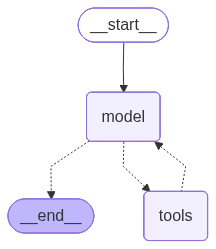

In [8]:
from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG 출력 실패:", e)
    print(agent.get_graph().draw_mermaid())

## 실행 예시

In [9]:
query = "일반적으로 직장인은 언제 연금을 수령할 수 있나요?"

result = agent.invoke({
    "messages": [
        {"role": "user", "content": query}
    ]
})

result

{'messages': [HumanMessage(content='일반적으로 직장인은 언제 연금을 수령할 수 있나요?', additional_kwargs={}, response_metadata={}, id='ba3764f0-b9ba-48d8-95fb-97d39e127e40'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 99, 'prompt_tokens': 688, 'total_tokens': 787, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'solar-mini-250422', 'system_fingerprint': None, 'id': '559d5f74-5ebb-4b54-8c8e-6f649fc37b13', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019efde3-bcac-7172-9c3a-5a4f1234f22c-0', tool_calls=[{'name': 'search_pension_law', 'args': {'query': '직장인 연금 수령 시기'}, 'id': '2884cff2-d0b2-44bf-b750-6f929961a3cb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 688, 'output_tokens': 99, 'total_

In [10]:
# 최종 답변 텍스트만 보고 싶을 때
final_message = result["messages"][-1]
print(final_message.content)

검색 결과, 직장인이 일반적으로 연금을 수령할 수 있는 시기에 대한 구체적인 정보는 없습니다. 국민연금 법령/문서에서 해당 정보를 찾을 수 없습니다. 다른 질문이 있으신가요?


In [11]:
# 선택 사항: 답변이 문서에 근거하는지 별도 검증
verification = verify_answer_with_docs(query, final_message.content)
print(verification)

근거성: 부족
도움성: 부족
설명: 검색 결과에서 직장인이 일반적으로 연금을 수령할 수 있는 시기에 대한 구체적인 정보를 찾지 못했다고 하면서도, 답변에는 해당 내용이 포함되어 있지 않아 검색 결과에 근거하고 있지 않습니다. 또한, 질문자가 원하는 정보를 제공하지 못하여 도움이 되지 않습니다.


## 기존 `graph.invoke({"query": ...})` 방식과 비슷하게 쓰고 싶은 경우

아래 래퍼를 사용하면 기존 예제와 유사하게 `graph.invoke({"query": 질문})` 형태로 호출할 수 있습니다.

In [12]:
class AgentGraphWrapper:
    """기존 StateGraph 예제의 graph.invoke({'query': ...}) 사용감을 맞추기 위한 간단한 래퍼입니다."""

    def __init__(self, agent):
        self.agent = agent

    def invoke(self, state: dict) -> dict:
        query = state.get("query") or state.get("question") or ""
        result = self.agent.invoke({
            "messages": [
                {"role": "user", "content": query}
            ]
        })
        answer = result["messages"][-1].content
        return {
            "query": query,
            "answer": answer,
            "messages": result["messages"],
        }

    def get_graph(self):
        return self.agent.get_graph()


graph = AgentGraphWrapper(agent)

In [13]:
graph.invoke({"query": "일반적으로 직장인은 언제 연금을 수령할 수 있나요?"})

{'query': '일반적으로 직장인은 언제 연금을 수령할 수 있나요?',
 'answer': '검색 결과, 사업장가입자의 연금 수령 시기에 대한 구체적인 정보를 찾을 수 없습니다. 국민연금 법령/문서에 따르면, 직장인은 일반적으로 60세부터 연금을 수령할 수 있습니다. 그러나 이는 개인의 가입 기간과 가입 유형에 따라 달라질 수 있습니다. 더 자세한 정보를 원하시면 국민연금공단에 문의하시는 것이 좋습니다.',
 'messages': [HumanMessage(content='일반적으로 직장인은 언제 연금을 수령할 수 있나요?', additional_kwargs={}, response_metadata={}, id='68a833a9-ab8a-448a-bc60-6bec889bf179'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 688, 'total_tokens': 776, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'solar-mini-250422', 'system_fingerprint': None, 'id': '992a66f7-ca15-47bf-a2ac-b11e5f7ab2af', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019efde4-398b-7643-b699-120fd88203e2-0', too